Saving Mall_Customers.csv to Mall_Customers (1).csv
First 5 rows:
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Unnamed: 5  Spending Score (1-100).1  
0         NaN                       NaN  
1         NaN                       NaN  
2         NaN                       NaN  
3         NaN                       NaN  
4         NaN                       NaN  

Shape: (200, 7)

Columns: Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Unnamed: 5', 'Spending Score (1-100).1'],
      dtype='object')

Cleaned Data:
    Gender  Age  Annual Income (k$) 

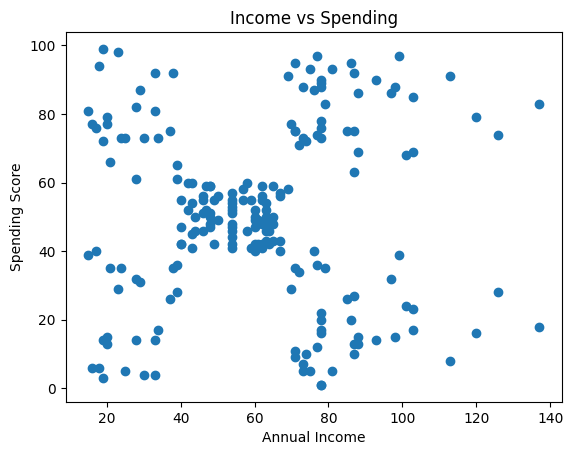

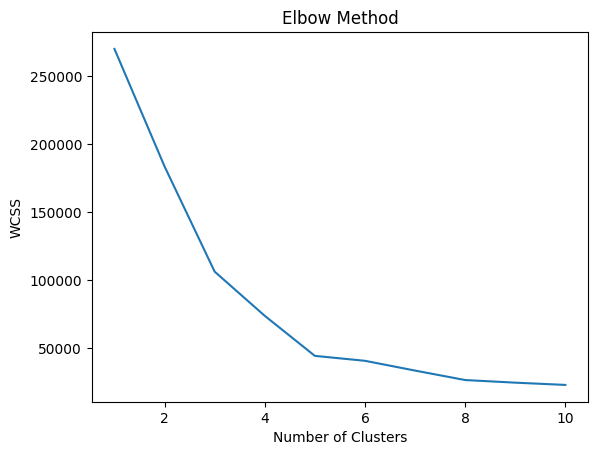


Clustered Data:
    Gender  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0       0   19                  15                      39        4
1       0   21                  15                      81        2
2       1   20                  16                       6        4
3       1   23                  16                      77        2
4       1   31                  17                      40        4


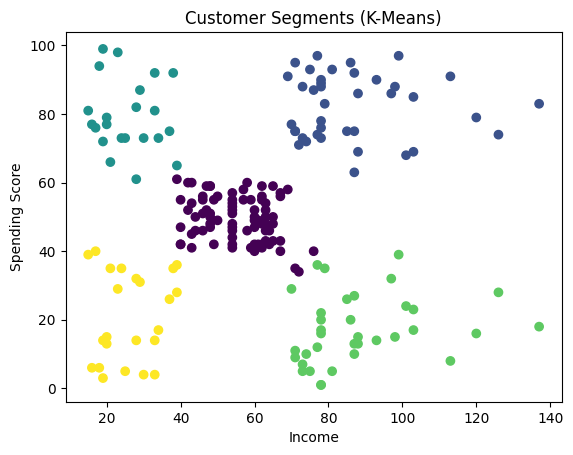

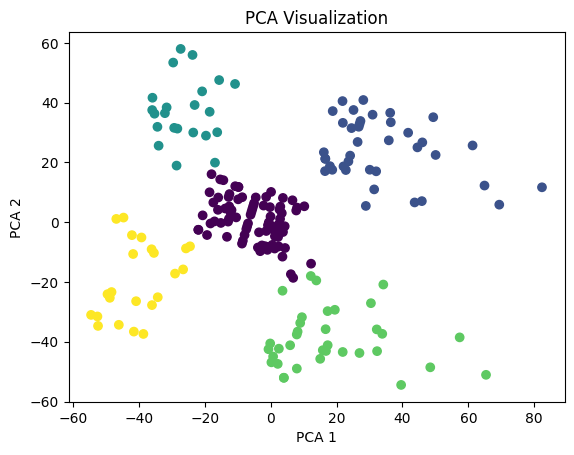

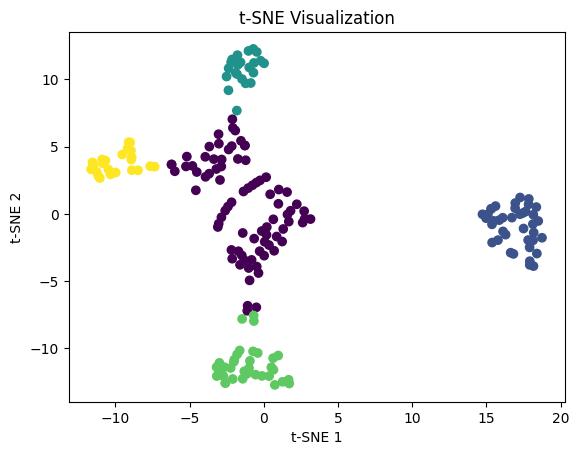


Cluster Summary:
            Gender        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                 
0        0.592593  42.716049           55.296296               49.518519
1        0.538462  32.692308           86.538462               82.128205
2        0.590909  25.272727           25.727273               79.363636
3        0.457143  41.114286           88.200000               17.114286
4        0.608696  45.217391           26.304348               20.913043

Silhouette Score: 0.553931997444648

Segmented file saved!

MARKETING STRATEGIES:

Cluster 0: High Income + High Spending → VIP customers → Premium offers, exclusive deals
Cluster 1: High Income + Low Spending → Targeted marketing, loyalty programs
Cluster 2: Low Income + High Spending → Discounts, flash sales
Cluster 3: Low Income + Low Spending → Budget promotions
Cluster 4: Average customers → Regular engagement


In [2]:
from google.colab import files
uploaded = files.upload()
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("Mall_Customers.csv")

print("First 5 rows:\n", df.head())
print("\nShape:", df.shape)
print("\nColumns:", df.columns)
# =========================
# 3. DATA CLEANING (FINAL)
# =========================

# Drop CustomerID
if 'CustomerID' in df.columns:
    df = df.drop('CustomerID', axis=1)

# Fix wrong column name
df.rename(columns={'Genre': 'Gender'}, inplace=True)

# Remove completely empty columns (IMPORTANT )
df = df.dropna(axis=1, how='all')

# Encode Gender
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

print("\nCleaned Data:\n", df.head())

# =========================
# 4. EDA (EXPLORATORY DATA ANALYSIS)
# =========================
print("\nMissing Values:\n", df.isnull().sum())
print("\nStatistical Summary:\n", df.describe())

# Scatter plot
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Income vs Spending")
plt.show()

# =========================
# 5. FEATURE SELECTION
# =========================
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# =========================
# 6. ELBOW METHOD
# =========================
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# =========================
# 7. K-MEANS CLUSTERING
# =========================
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

print("\nClustered Data:\n", df.head())

# =========================
# 8. CLUSTER VISUALIZATION
# =========================
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'], c=df['Cluster'])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments (K-Means)")
plt.show()

# =========================
# 9. PCA VISUALIZATION
# =========================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Cluster'])
plt.title("PCA Visualization")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# =========================
# 10. t-SNE VISUALIZATION
# =========================
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=df['Cluster'])
plt.title("t-SNE Visualization")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

# =========================
# 11. CLUSTER ANALYSIS
# =========================
cluster_summary = df.groupby('Cluster').mean()
print("\nCluster Summary:\n", cluster_summary)

# =========================
# 12. MODEL EVALUATION
# =========================
score = silhouette_score(X, df['Cluster'])
print("\nSilhouette Score:", score)

# =========================
# 13. SAVE FINAL DATA
# =========================
df.to_csv("Mall_Customers_Segmented.csv", index=False)
print("\nSegmented file saved!")

# =========================
# 14. MARKETING STRATEGIES (PRINT)
# =========================
print("\nMARKETING STRATEGIES:\n")

print("Cluster 0: High Income + High Spending → VIP customers → Premium offers, exclusive deals")
print("Cluster 1: High Income + Low Spending → Targeted marketing, loyalty programs")
print("Cluster 2: Low Income + High Spending → Discounts, flash sales")
print("Cluster 3: Low Income + Low Spending → Budget promotions")
print("Cluster 4: Average customers → Regular engagement")